In [1]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z_offset = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e
eps = 1
alpha = 1/137.06
m_dm = 1e-27 # modified
m_ion = c.m 
Z_charge = c.Z
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega = 2*pi*np.array([freq_x,freq_y,freq_z])
hbar = 1.0545718e-34 

In [2]:
# RF pseudo-force
def FRF(x,y,z,m=c.m,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    # --- FORCE EVERYTHING TO SCALARS ---
    x = float(x)
    y = float(y)
    z = float(z)
    m = float(np.asarray(m).ravel()[0])
    q = float(np.asarray(q).ravel()[0])
    omrf = float(np.asarray(omrf).ravel()[0])
    VRF = float(np.asarray(VRF).ravel()[0])
    Zc = float(np.asarray(Z_charge).ravel()[0])
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z) 
    divyparty=-2*divypart*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y)) 
    divypartz=2*divypart*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y)) 
    divzparty=-2*divzpart*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    divzpartz=2*divzpart*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z)) 
    return -1*((VRF*Z_charge*q)/(2*pi*np.sqrt(m)*omrf))**2*np.array([divypartz*0,divzparty+divyparty,divzpartz+divypartz])

# DC force
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def anatangrad(xi,yi,x,y,z,v): # gradient term of DC potential
    dy=y-yi
    dx=x-xi
    r = np.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return (v/(2*np.pi))*np.array([divx,divy,divz])

def FDC_single(x1,y1,x2,y2,x,y,z,v):
    return -Z_charge*e * (anatangrad(x2,y2,x,y,z,v)-anatangrad(x2,y1,x,y,z,v)-anatangrad(x1,y2,x,y,z,v)+anatangrad(x1,y1,x,y,z,v))

def FDC(x, y, z, m=c.m, q=c.e, omrf=c.omega,
        ymin=c.y11, yedge1=c.y21, yedge2=c.y12, ymax=c.y22):
    z_original = z
    force = np.zeros(3, dtype=float)
    # local copies forced to scalars (if these could be arrays)
    x = float(x); y = float(y); z_original = float(z_original)
    for k in range(0, 40):
        if (k != 19 and k != 39):
            z = z_original - z_offset  # keep scalar math
        else:
            z = z_original
        (x1k, y1k) = xy1k[k]
        (x2k, y2k) = xy2k[k]
        # enforce scalar on vk[k]
        v_k = float(np.asarray(vk[k]).ravel()[0])
        force_single = FDC_single(x1k, y1k, x2k, y2k, x, y, z, v_k)
        # ensure force_single is shape (3,)
        force_single = np.asarray(force_single, dtype=float).ravel()
        if force_single.shape != (3,):
            raise ValueError(f"FDC_single returned unexpected shape {force_single.shape} at k={k}")
        force += force_single
        # restore z (already set above each iteration; explicit restore optional)
        z = z_original
    return force

Initial ion positions: [[-3.7e-06  0.0e+00 -0.0e+00]
 [ 0.0e+00 -0.0e+00  0.0e+00]
 [ 3.7e-06  0.0e+00  0.0e+00]]
Initial DM position: [0.e+00 5.e-06 0.e+00]
Initial DM velocity: [  0. 500.   0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 3e-09


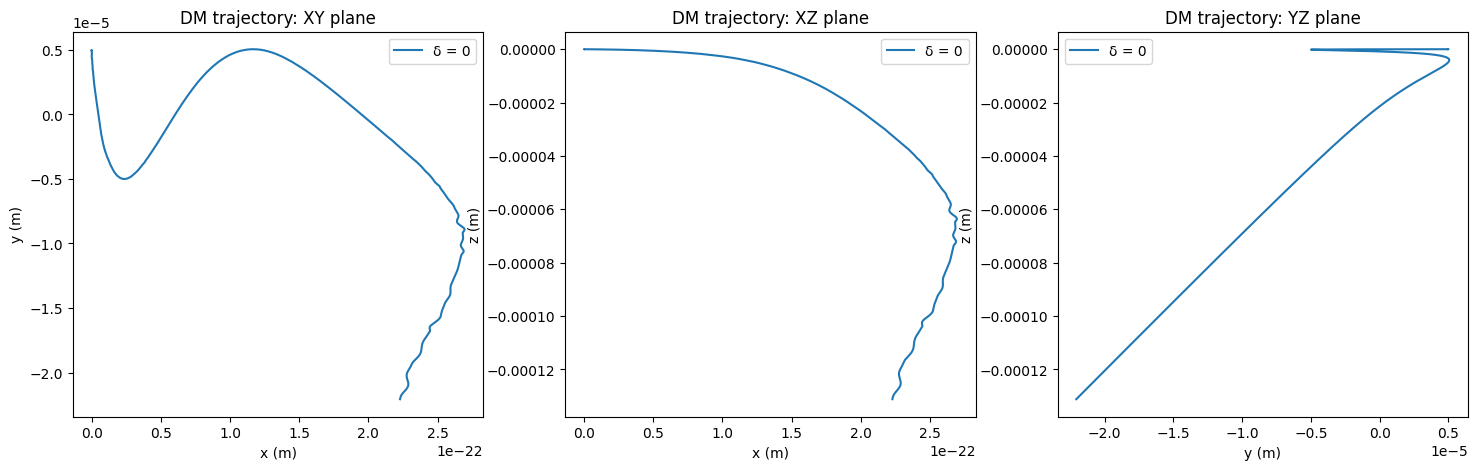

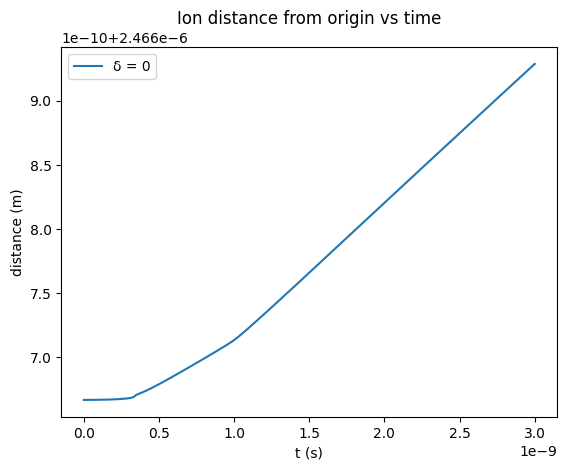

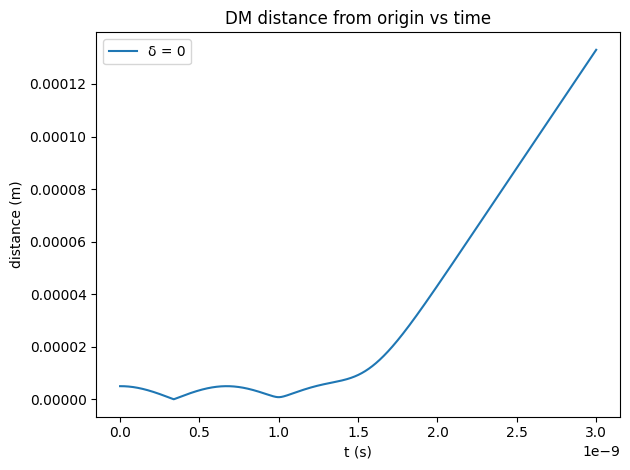

Time: 1.862431215607804e-09 s
DM position at 1.862431215607804e-09 s: 2.204163829643592e-22,-2.328480149414362e-06,-3.1345202443496895e-05
DM velocity at 1.862431215607804e-09 s: 1.930218454903194e-13,-18024.119934083225,-82212.14800628264
DM distance at 1.862431215607804e-09 s: 3.1431569099076496e-05


In [3]:
# 2.Back propagate DM from 5um distance to 30um distance, and record final position and velocity.
def run_simulation(delta):
    d_chain = 3.7e-6  # 3.7 µm separation

    # scalars for directions
    phi1 = 2*np.pi*np.random.random()
    theta1 = 2*np.pi*np.random.random()
    phi2 = 2*np.pi*np.random.random()
    theta2 = 2*np.pi*np.random.random()
    phi3 = 2*np.pi*np.random.random()
    theta3 = 2*np.pi*np.random.random()

    x0_ions = np.array([
        [-d_chain + delta*np.cos(theta1)*np.sin(phi1),
         delta*np.sin(theta1)*np.sin(phi1),
         delta*np.cos(phi1)],

        [ delta*np.cos(theta2)*np.sin(phi2),
          delta*np.sin(theta2)*np.sin(phi2),
          delta*np.cos(phi2)],

        [ d_chain + delta*np.cos(theta3)*np.sin(phi3),
          delta*np.sin(theta3)*np.sin(phi3),
          delta*np.cos(phi3)]
    ], dtype=float)

    v0_ions = np.zeros_like(x0_ions, dtype=float)
    print("Initial ion positions:", x0_ions)

    # Initial condition for DM (close to ions)
    x0_dm = np.array([0.0, 5e-6, 0.0], dtype=float)  
    v0_dm = np.array([0.0, 500, 0.0], dtype=float)
    print("Initial DM position:", x0_dm)
    print("Initial DM velocity:", v0_dm)

    # Flatten initial state
    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # short-range regularization
    rcut = 1e-9

    # ODE system 
    def fun2(t, U):
        """
        Robust ODE RHS:
        - uses Plummer softening for Coulomb: replace r^3 by (r^2 + a^2)^(3/2)
        - calls FRF/FDC with Python floats and reduces any (3,N) output to the column nearest t
        """
        n_ions = 3
        x_ions = U[0:3*n_ions].reshape((n_ions,3))
        x_dm   = U[3*n_ions:3*n_ions+3].astype(float)
        v_ions = U[3*n_ions+3:3*n_ions+3*n_ions+3].reshape((n_ions,3))
        v_dm   = U[-3:].astype(float)

        # --- trap field calls (safe scalars) ---
        dc_raw = np.array(FDC(float(x_dm[0]), float(x_dm[1]), float(x_dm[2]))).reshape(3,)
        rf_raw = np.array(FRF(float(x_dm[0]), float(x_dm[1]), float(x_dm[2]))).reshape(3,)

        dc_force = dc_raw
        rf_force = rf_raw

        E_trap = (dc_force + rf_force) / e   # V/m at DM (3,)

        # --- softening parameter: Plummer softening length 'a' (meters) ---
        # choose a ~ (1e-8 ... 1e-6) m depending on how close particles get.
        # set conservatively so no tiny denominators: e.g. a_soft = 1e-7 (0.1 µm)
        a_soft = 1e-7
        a2 = a_soft * a_soft

        # derivatives containers
        dx_ionsdt = v_ions
        dv_ionsdt = np.zeros_like(x_ions)

        # Ion equations
        for i in range(n_ions):
            # harmonic trap
            dv_ionsdt[i] += -omega**2 * x_ions[i]

            # Coulomb with DM using Plummer softening:
            delta_dm = x_ions[i] - x_dm
            r2_dm = np.dot(delta_dm, delta_dm)
            denom_dm = (r2_dm + a2)**1.5   # (r^2 + a^2)^(3/2)
            dv_ionsdt[i] += K * eps * e**2 * delta_dm / (m_ion * denom_dm)

            # Coulomb with other ions (softened)
            for j in range(n_ions):
                if i == j:
                    continue
                delta_ij = x_ions[i] - x_ions[j]
                r2_ij = np.dot(delta_ij, delta_ij)
                denom_ij = (r2_ij + a2)**1.5
                dv_ionsdt[i] += K * e**2 * delta_ij / (m_ion * denom_ij)

        # DM motion: trap contribution from E_trap plus Coulomb softening with ions
        dx_dmdt = v_dm
        # trap acceleration 
        E_trap = (dc_force + rf_force) / e      # if they are forces
        a_dm_trap = (eps * e / m_dm) * E_trap
        dv_dmdt = a_dm_trap.copy()

        for i in range(n_ions):
            delta_dm2 = x_dm - x_ions[i]
            r2_dm2 = np.dot(delta_dm2, delta_dm2)
            denom_dm2 = (r2_dm2 + a2)**1.5
            dv_dmdt += -K * eps * e**2 * delta_dm2 / (m_dm * denom_dm2)

        return np.concatenate([
            dx_ionsdt.flatten(), dx_dmdt,
            dv_ionsdt.flatten(), dv_dmdt
        ])

    # Solve
    t_eval = np.linspace(0, 3e-9, 2000)
    t_span = (t_eval[0], t_eval[-1])
    sol = solve_ivp(fun2, t_span, U0, method='DOP853',
                    t_eval=t_eval, dense_output=True,
                    rtol=1e-11, atol=1e-11)

    print("Success?", sol.success)
    print("Message:", sol.message)
    print("Final time:", sol.t[-1])

    # Extract solutions
    n_ions = 3
    x_ions_sol = sol.y[0:3*n_ions]
    x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]   # (3, N)
    v_ions_sol = sol.y[3*n_ions+3:3*n_ions+3*n_ions+3]
    v_dm_sol   = sol.y[-3:]

    return t_eval, x_dm_sol, v_dm_sol, x_ions_sol

# Run a single simulation and plot the DM trajectory 
delta = 100e-6
t0, xdm, vdm, xion = run_simulation(0.0)

# dm0 shape should be (3, N)
x0, y0, z0 = xdm
d = np.sqrt(x0**2 + y0**2 + z0**2)
ion0_rs = xion.reshape(3, 3, -1)
xion = ion0_rs[:, 0, :]
yion = ion0_rs[:, 1, :]
zion = ion0_rs[:, 2, :]
d_ion = np.sqrt(xion**2 + yion**2 + zion**2)  # shape (3, N)
d_ion_mean = d_ion.mean(axis=0)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(x0, y0, label="δ = 0")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("DM trajectory: XY plane")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(x0, z0, label="δ = 0")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: XZ plane")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(y0, z0, label="δ = 0")
plt.xlabel("y (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: YZ plane")
plt.legend()

plt.figure()
plt.plot(t0, d_ion_mean, label="δ = 0")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("Ion distance from origin vs time")
plt.legend()

plt.figure()
plt.plot(t0, d, label="δ = 0")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("DM distance from origin vs time")
plt.legend()

plt.tight_layout()
plt.show()

# Extract ion position and velocity at t=0.65e-5s
print(f"Time: {t0[1241]} s")
print(f"DM position at {t0[1241]} s: {xdm[0][1241]},{xdm[1][1241]},{xdm[2][1241]}")
print(f"DM velocity at {t0[1241]} s: {vdm[0][1241]},{vdm[1][1241]},{vdm[2][1241]}")
print(f"DM distance at {t0[1241]} s: {d[1241]}")

Initial ion positions: [[-3.7e-06 -0.0e+00  0.0e+00]
 [ 0.0e+00 -0.0e+00  0.0e+00]
 [ 3.7e-06  0.0e+00  0.0e+00]]
Initial DM position: [ 2.11297150e-22 -2.32848015e-06 -3.13452024e-05]
Initial DM velocity: [-1.74379576e-13  1.80241199e+04  8.22121480e+04]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 5e-06
Initial ion positions: [[-8.17376376e-05  1.65708599e-05 -6.02953873e-05]
 [-7.61097370e-05 -4.82652947e-05 -4.33332352e-05]
 [ 6.30365682e-06 -7.27176742e-05 -6.85956328e-05]]
Initial DM position: [ 2.11297150e-22 -2.32848015e-06 -3.13452024e-05]
Initial DM velocity: [-1.74379576e-13  1.80241199e+04  8.22121480e+04]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 5e-06
Ending position of DM: [ 1.87794931e-18 -8.56854357e-02 -4.40800824e-01]
Ending velocity of DM: [ 3.75268878e-13 -1.71491912e+04 -8.82197851e+04]


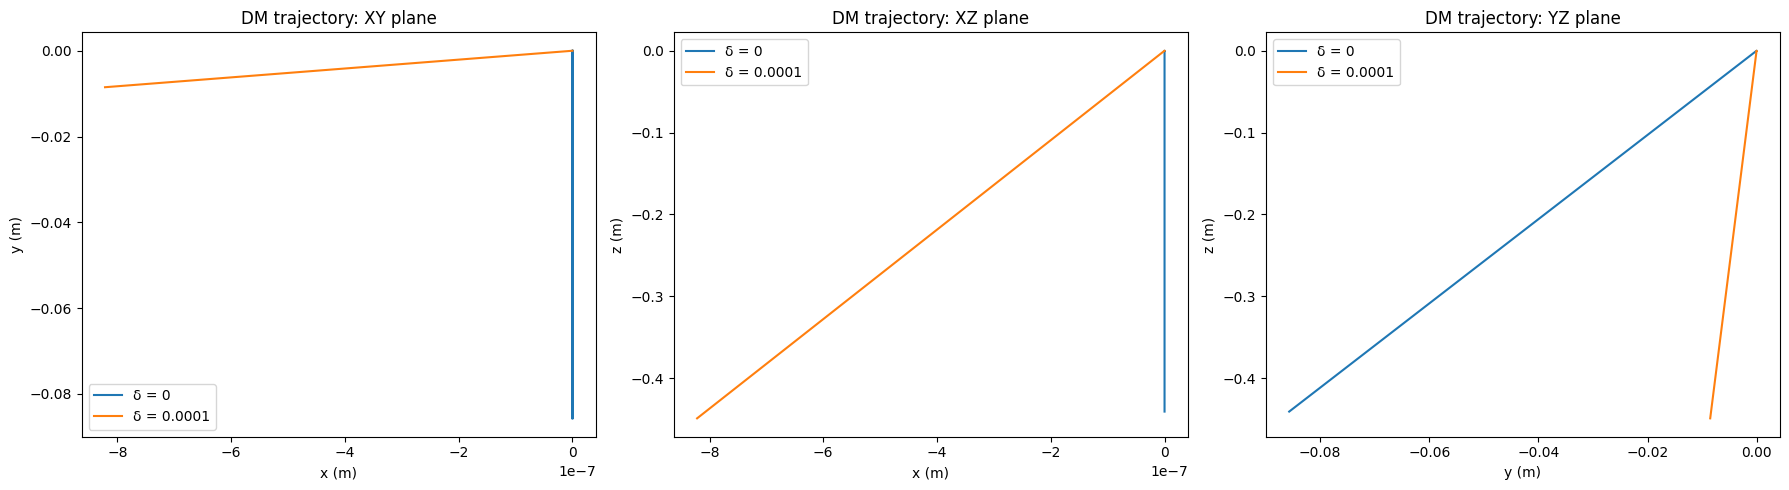

Average trajectory deviation of dark matter between δ=0 and δ=1e-6: 3.878406e-02 m


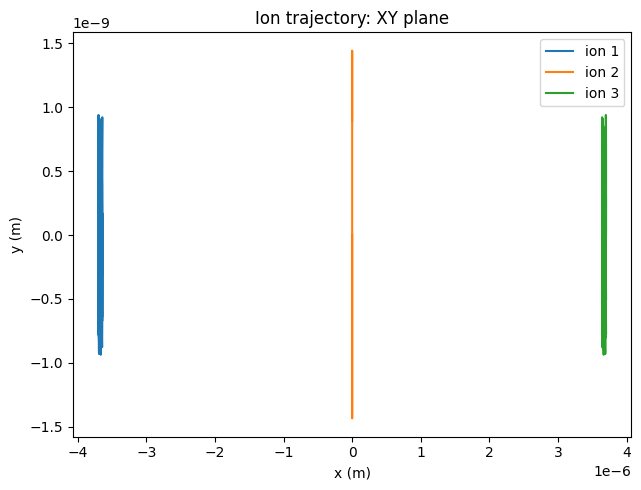

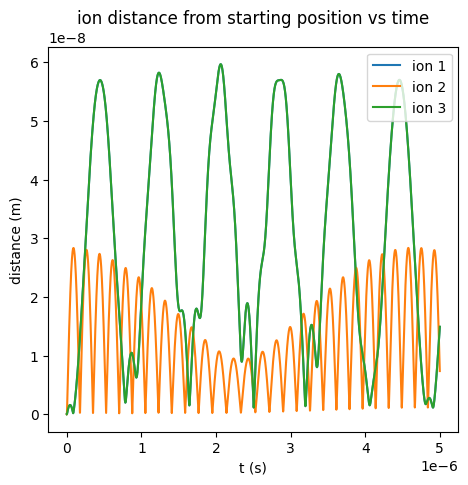

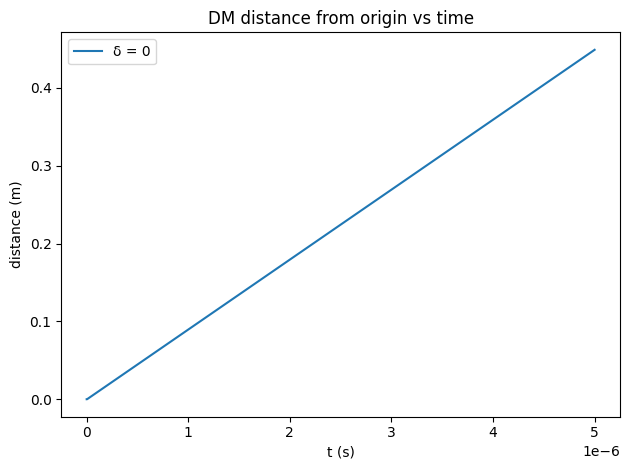

In [4]:
## 3. Simulate dark matter trajectory using ion trap potential with initial condition (obtained from #2) at 30um distance. Observe signals of phonons generated by dark matter.

def run_simulation(delta):
    d_chain = 3.7e-6  # 3.7 µm separation

    # scalars for directions
    phi1 = 2*np.pi*np.random.random()
    theta1 = 2*np.pi*np.random.random()
    phi2 = 2*np.pi*np.random.random()
    theta2 = 2*np.pi*np.random.random()
    phi3 = 2*np.pi*np.random.random()
    theta3 = 2*np.pi*np.random.random()

    x0_ions = np.array([
        [-d_chain + delta*np.cos(theta1)*np.sin(phi1),
         delta*np.sin(theta1)*np.sin(phi1),
         delta*np.cos(phi1)],

        [ delta*np.cos(theta2)*np.sin(phi2),
          delta*np.sin(theta2)*np.sin(phi2),
          delta*np.cos(phi2)],

        [ d_chain + delta*np.cos(theta3)*np.sin(phi3),
          delta*np.sin(theta3)*np.sin(phi3),
          delta*np.cos(phi3)]
    ], dtype=float)

    v0_ions = np.zeros_like(x0_ions, dtype=float)
    print("Initial ion positions:", x0_ions)

    # Initial condition for DM (from simulation in #3): can modify impact parameter b
    b = 0e-6 # impact parameter
    x0_dm = np.array([2.1129714985500633e-22,-2.3284801494144364e-06,-3.134520244349659e-05], dtype=float)  
    v0_dm = np.array([-1.7437957579651323e-13,18024.119934083286,82212.14800628253], dtype=float)
    print("Initial DM position:", x0_dm)
    print("Initial DM velocity:", v0_dm)

    # Flatten initial state
    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # short-range regularization
    rcut = 1e-9

    # ODE system 
    def fun2(t, U):
        """
        Robust ODE RHS:
        - uses Plummer softening for Coulomb: replace r^3 by (r^2 + a^2)^(3/2)
        - calls FRF/FDC with Python floats and reduces any (3,N) output to the column nearest t
        """
        n_ions = 3
        x_ions = U[0:3*n_ions].reshape((n_ions,3))
        x_dm   = U[3*n_ions:3*n_ions+3].astype(float)
        v_ions = U[3*n_ions+3:3*n_ions+3*n_ions+3].reshape((n_ions,3))
        v_dm   = U[-3:].astype(float)

        # --- trap field calls (safe scalars) ---
        dc_raw = FDC(float(x_dm[0]), float(x_dm[1]), float(x_dm[2]))
        rf_raw = FRF(float(x_dm[0]), float(x_dm[1]), float(x_dm[2]))

        dc_arr = np.asarray(dc_raw)
        rf_arr = np.asarray(rf_raw)

        def reduce_to_vec(arr, name):
            arr = np.asarray(arr)
            if arr.shape == (3,):
                return arr.ravel()
            if arr.ndim == 2 and arr.shape[0] == 3:
                # if t_eval exists and matches, pick nearest column; otherwise average columns
                if 't_eval' in globals() and arr.shape[1] == len(t_eval):
                    idx = np.argmin(np.abs(t_eval - t))
                    # one-time warn
                    if not getattr(reduce_to_vec, f"_warned_{name}", False):
                        print(f"Warning: {name} returned shape {arr.shape}; using column {idx} (t~{t_eval[idx]:.3e})")
                        setattr(reduce_to_vec, f"_warned_{name}", True)
                    return arr[:, idx].ravel()
                else:
                    # fallback: average across time (less ideal, but safe)
                    if not getattr(reduce_to_vec, f"_warned_{name}_avg", False):
                        print(f"Warning: {name} returned shape {arr.shape}; averaging across time to produce (3,) vector")
                        setattr(reduce_to_vec, f"_warned_{name}_avg", True)
                    return arr.mean(axis=1).ravel()
            raise ValueError(f"{name} returned unsupported shape {arr.shape}. Expected (3,) or (3,N).")

        dc_force = reduce_to_vec(dc_arr, "FDC")
        rf_force = reduce_to_vec(rf_arr, "FRF")

        E_trap = (dc_force + rf_force) / e   # V/m at DM (3,)

        # --- softening parameter: Plummer softening length 'a' (meters) ---
        # choose a ~ (1e-8 ... 1e-6) m depending on how close particles get.
        # set conservatively so no tiny denominators: e.g. a_soft = 1e-7 (0.1 µm)
        a_soft = 1e-7
        a2 = a_soft * a_soft

        # derivatives containers
        dx_ionsdt = v_ions
        dv_ionsdt = np.zeros_like(x_ions)

        # Ion equations
        for i in range(n_ions):
            # harmonic trap
            dv_ionsdt[i] += -omega**2 * x_ions[i]

            # Coulomb with DM using Plummer softening:
            delta_dm = x_ions[i] - x_dm
            r2_dm = np.dot(delta_dm, delta_dm)
            denom_dm = (r2_dm + a2)**1.5   # (r^2 + a^2)^(3/2)
            dv_ionsdt[i] += K * eps * e**2 * delta_dm / (m_ion * denom_dm)

            # Coulomb with other ions (softened)
            for j in range(n_ions):
                if i == j:
                    continue
                delta_ij = x_ions[i] - x_ions[j]
                r2_ij = np.dot(delta_ij, delta_ij)
                denom_ij = (r2_ij + a2)**1.5
                dv_ionsdt[i] += K * e**2 * delta_ij / (m_ion * denom_ij)
        
        # DM motion: trap contribution from E_trap plus Coulomb softening with ions
        dx_dmdt = v_dm
        # trap acceleration 
        E_trap = (dc_force + rf_force) / e      # if they are forces
        a_dm_trap = (eps * e / m_dm) * E_trap
        dv_dmdt = a_dm_trap.copy()

        for i in range(n_ions):
            delta_dm2 = x_dm - x_ions[i]
            r2_dm2 = np.dot(delta_dm2, delta_dm2)
            denom_dm2 = (r2_dm2 + a2)**1.5
            dv_dmdt += -K * eps * e**2 * delta_dm2 / (m_dm * denom_dm2)

        return np.concatenate([
            dx_ionsdt.flatten(), dx_dmdt,
            dv_ionsdt.flatten(), dv_dmdt
        ])

    # Solve
    t_eval = np.linspace(0, 5e-6, 5000)
    t_span = (t_eval[0], t_eval[-1])
    sol = solve_ivp(fun2, t_span, U0, method='DOP853',
                    t_eval=t_eval, dense_output=True,
                    rtol=1e-11, atol=1e-11)

    print("Success?", sol.success)
    print("Message:", sol.message)
    print("Final time:", sol.t[-1])

    # Extract solutions
    n_ions = 3
    x_ions_sol = sol.y[0:3*n_ions]
    x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]   # (3, N)
    v_ions_sol = sol.y[3*n_ions+3:3*n_ions+3*n_ions+3]
    v_dm_sol   = sol.y[-3:]

    return t_eval, x_dm_sol, v_dm_sol, x_ions_sol

# Run simulations
delta=100e-6  # adjust delta
t0, xdm0, vdm0, xion0 = run_simulation(0.0) 
t1, xdm1, vdm1, xion1 = run_simulation(delta)  

# dm0, dm1 shapes: (3, N)
x0, y0, z0 = xdm0
x1, y1, z1 = xdm1
x0_ion1, y0_ion1, z0_ion1 = xion0[0], xion0[1], xion0[2] # motion of left ion
x1_ion1, y1_ion1, z1_ion1 = xion1[0], xion1[1], xion1[2]
x0_ion2, y0_ion2, z0_ion2 = xion0[3], xion0[4], xion0[5] # motion of center ion
x1_ion2, y1_ion2, z1_ion2 = xion1[3], xion1[4], xion1[5]
x0_ion3, y0_ion3, z0_ion3 = xion0[6], xion0[7], xion0[8] # motion of right ion
x1_ion3, y1_ion3, z1_ion3 = xion1[6], xion1[7], xion1[8]
d_chain = 3.7e-6  # 3.7 µm separation
d = np.sqrt(x0**2 + y0**2 + z0**2) # for DM
d_ion1 = np.sqrt((x0_ion1+d_chain)**2+y0_ion1**2+z0_ion1**2)
d_ion2 = np.sqrt(x0_ion2**2+y0_ion2**2+z0_ion2**2)
d_ion3 = np.sqrt((x0_ion3-d_chain)**2+y0_ion3**2+z0_ion3**2)
print(f"Ending position of DM: {xdm0[:, -1]}")
print(f"Ending velocity of DM: {vdm0[:, -1]}")

# 1) Plots of the DM trajectory
plt.figure(figsize=(18,5))

# XY
plt.subplot(1,3,1)
plt.plot(x0, y0, label="δ = 0")
plt.plot(x1, y1, label=f"δ = {delta}")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("DM trajectory: XY plane")
plt.legend()

# XZ
plt.subplot(1,3,2)
plt.plot(x0, z0, label="δ = 0")
plt.plot(x1, z1, label=f"δ = {delta}")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: XZ plane")
plt.legend()

# YZ
plt.subplot(1,3,3)
plt.plot(y0, z0, label="δ = 0")
plt.plot(y1, z1, label=f"δ = {delta}")
plt.xlabel("y (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: YZ plane")
plt.legend()

plt.tight_layout()
plt.show()

# 2) Quantify deviation between δ=0 and δ=1e-6 runs
distances = np.sqrt((x1 - x0)**2 + (y1 - y0)**2 + (z1 - z0)**2)
avg_deviation = np.mean(distances)
print(f"Average trajectory deviation of dark matter between δ=0 and δ=1e-6: {avg_deviation:.6e} m")

# 3) Plots for ion trajectory: δ=0
plt.figure(figsize=(18,5))

# ion 1 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion1, y0_ion1, label="ion 1")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

# ion 2 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion2, y0_ion2, label="ion 2")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

# ion 3 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion3, y0_ion3, label="ion 3")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

plt.tight_layout()
plt.show()

# ion 1 distance vs time
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.plot(t0, d_ion1, label="ion 1")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# ion 2 distance vs time
plt.subplot(1,3,1)
plt.plot(t0, d_ion2, label="ion 2")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# ion 3 distance vs time
plt.subplot(1,3,1)
plt.plot(t0, d_ion3, label="ion 3")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# DM distance vs time
plt.figure()
plt.plot(t0, d, label="δ = 0")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("DM distance from origin vs time")
plt.legend()

plt.tight_layout()
plt.show()


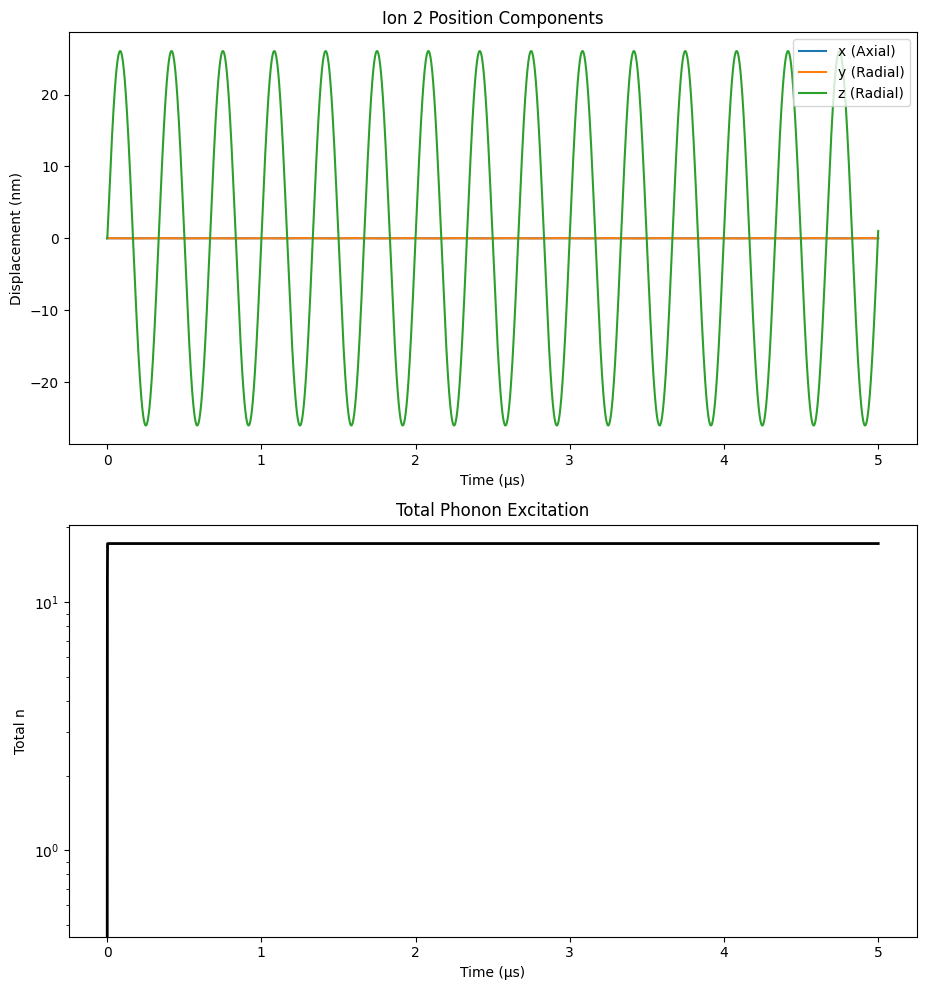

Energy in x-direction: 6.180109462412097e-57 J
Energy in y-direction: 2.869132690923901e-32 J
Energy in z-direction: 3.4270234895900423e-26 J
Number of phonons in x-direction: 1.2964362648845327e-29
Number of phonons in y-direction: 1.4284992542659589e-05
Number of phonons in z-direction: 17.227733950913212
Peak Total Phonons: 17.228680747335307


In [5]:
## 4. Calculate the number of phonons excited in Ion 2 (ignoring Ion 1 and Ion 3)

def run_simulation_full_phonons(delta):
    d_chain = 3.7e-6 
    
    # Initial ion positions
    x0_ions = np.array([[-d_chain, 0, 0], [0, 0, 0], [d_chain, 0, 0]], dtype=float)
    x0_ions[1] += delta * np.random.normal(size=3) 
    v0_ions = np.zeros_like(x0_ions)
    
    # DM Initial conditions
    b = 4e-6 
    x0_dm = np.array([2.1129714985500633e-22,-2.3284801494144364e-06,-3.134520244349659e-05], dtype=float)  
    v0_dm = np.array([-1.7437957579651323e-13,18024.119934083286,82212.14800628253], dtype=float)
    #x0_dm = np.array([2.1129714985500633e-22 + b, -2.3284801494144364e-06, -3.134520244349659e-05])  
    #v0_dm = np.array([-1.7437957579651323e-13, 18024.119934083286, 82212.14800628253])

    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm])

    def fun2(t, U):
        x_ions = U[0:9].reshape((3, 3))
        x_dm   = U[9:12]
        v_ions = U[12:21].reshape((3, 3))
        v_dm   = U[21:24]

        # Force on DM from trap
        dc_force = np.asarray(FDC(x_dm[0], x_dm[1], x_dm[2])).flatten()
        rf_force = np.asarray(FRF(x_dm[0], x_dm[1], x_dm[2])).flatten()
        E_trap_dm = (dc_force + rf_force) / e 

        a_soft = 1e-7
        a2 = a_soft**2

        dv_ionsdt = np.zeros((3, 3))
        dv_dmdt = (eps * e / m_dm) * E_trap_dm

        target_ion = 1
        # 1. Harmonic Trap with directional omega
        # acceleration = -omega^2 * x for each component
        dv_ionsdt[target_ion] = -(omega**2) * x_ions[target_ion]

        # 2. Interaction with DM
        delta_dm = x_ions[target_ion] - x_dm
        r2_dm = np.dot(delta_dm, delta_dm)
        dv_ionsdt[target_ion] += K * eps * e**2 * delta_dm / (m_ion * (r2_dm + a2)**1.5)

        # 3. DM feedback
        delta_dm_rev = x_dm - x_ions[target_ion]
        r2_dm_rev = np.dot(delta_dm_rev, delta_dm_rev)
        dv_dmdt += -K * eps * e**2 * delta_dm_rev / (m_dm * (r2_dm_rev + a2)**1.5)
        
        return np.concatenate([v_ions.flatten(), v_dm, dv_ionsdt.flatten(), dv_dmdt])

    t_eval = np.linspace(0, 5e-6, 5000)
    sol = solve_ivp(fun2, (0, 1e-5), U0, method='DOP853', t_eval=t_eval, rtol=1e-11)

    return sol.t, sol.y[9:12], sol.y[3:6], sol.y[15:18]

# --- Execution ---
t, xdm, x2, v2 = run_simulation_full_phonons(0.0)

# --- Phonon Analysis per Axis ---
# Energy E = 1/2 m v^2 + 1/2 m omega^2 r^2
E_x = 0.5 * m_ion * (v2[0]**2 + (omega[0]**2 * x2[0]**2))
E_y = 0.5 * m_ion * (v2[1]**2 + (omega[1]**2 * x2[1]**2))
E_z = 0.5 * m_ion * (v2[2]**2 + (omega[2]**2 * x2[2]**2))

# n = E / (hbar * omega)
n_x = E_x / (hbar * omega[0])
n_y = E_y / (hbar * omega[1])
n_z = E_z / (hbar * omega[2])
n_total = n_x + n_y + n_z

# --- Plotting ---
fig = plt.figure(figsize=(18, 10))
"""
# Plot 1: DM 3D Trajectory
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot(xdm[0], xdm[1], xdm[2], color='purple')
ax1.set_title("DM 3D Trajectory")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
"""

# Plot 2: Ion 2 Position Components
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(t * 1e6, x2[0]*1e9, label='x (Axial)')
ax2.plot(t * 1e6, x2[1]*1e9, label='y (Radial)')
ax2.plot(t * 1e6, x2[2]*1e9, label='z (Radial)')
ax2.set_title("Ion 2 Position Components")
ax2.set_xlabel("Time (µs)")
ax2.set_ylabel("Displacement (nm)")
ax2.legend()

"""
# Plot 3: Phonons per Axis
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(t * 1e6, n_x, label='n_x', alpha=0.7)
ax3.plot(t * 1e6, n_y, label='n_y', alpha=0.7)
ax3.plot(t * 1e6, n_z, label='n_z', alpha=0.7)
ax3.set_title("Phonons per Axis")
ax3.set_xlabel("Time (µs)")
ax3.set_ylabel("n (quanta)")
ax3.set_yscale('log')
ax3.legend()
"""

# Plot 4: Total Phonons
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(t * 1e6, n_total, color='black', linewidth=2)
ax4.set_title("Total Phonon Excitation")
ax4.set_xlabel("Time (µs)")
ax4.set_ylabel("Total n")
ax4.set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Energy in x-direction: {E_x[-1]} J")
print(f"Energy in y-direction: {E_y[-1]} J")
print(f"Energy in z-direction: {E_z[-1]} J")
print(f"Number of phonons in x-direction: {n_x[-1]}")
print(f"Number of phonons in y-direction: {n_y[-1]}")
print(f"Number of phonons in z-direction: {n_z[-1]}")
print(f"Peak Total Phonons: {np.max(n_total)}")